# Step 3 (v2) - Train Symbol Classifier on CROHME Dataset

Retrain the CNN using **CROHME-extracted isolated symbols** for better handwriting recognition.

Two datasets combined:
- **xainano/handwrittenmathsymbols** - 100k+ symbols (45x45 JPG) extracted from CROHME competition data
- **sagyamthapa/handwritten-math-symbols** - 10k real-world handwritten symbols (400x400), includes `=` sign

CROHME = Competition on Recognition of Online Handwritten Mathematical Expressions (ICDAR benchmark).

Run this on **Google Colab with T4 GPU**.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np
import os
import cv2
import glob
import json
from collections import Counter
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print(f'TF version: {tf.__version__}')
print(f'GPU available: {tf.config.list_physical_devices("GPU")}')

TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Download datasets from Kaggle

Two CROHME-based datasets with pre-extracted isolated symbol images.

In [5]:
# install kaggle API
!pip install -q kaggle

# dataset 1: CROHME extracted symbols (100k+, 45x45)
!kaggle datasets download -d xainano/handwrittenmathsymbols -q -p /content/ds1
# this downloads as zip containing data.rar
import zipfile
zip1 = '/content/ds1/handwrittenmathsymbols.zip'
if os.path.exists(zip1):
    with zipfile.ZipFile(zip1, 'r') as z:
        z.extractall('/content/ds1/')
    print('unzipped dataset 1')

# need unrar for the .rar inside
rar_path = '/content/ds1/data.rar'
if os.path.exists(rar_path):
    !apt-get install -qq unrar
    !unrar x -o+ {rar_path} /content/ds1/extracted/
    print('extracted rar')

# dataset 2: handwritten math symbols (10k, 400x400)
!kaggle datasets download -d sagyamthapa/handwritten-math-symbols -q -p /content/ds2
zip2 = '/content/ds2/handwritten-math-symbols.zip'
if os.path.exists(zip2):
    with zipfile.ZipFile(zip2, 'r') as z:
        z.extractall('/content/ds2/')
    print('unzipped dataset 2')

print('done downloading')

Streaming output truncated to the last 5000 lines.
Extracting  /content/ds1/extracted/extracted_images/z/exp75787.jpg        98%  OK 
Extracting  /content/ds1/extracted/extracted_images/z/exp75789.jpg        98%  OK 
Extracting  /content/ds1/extracted/extracted_images/z/exp75831.jpg        98%  OK 
Extracting  /content/ds1/extracted/extracted_images/z/exp75832.jpg        98%  OK 
Extracting  /content/ds1/extracted/extracted_images/z/exp75834.jpg        98%  OK 
Extracting  /content/ds1/extracted/extracted_images/z/exp75838.jpg        98%  OK 
Extracting  /content/ds1/extracted/extracted_images/z/exp7585.jpg         98%  OK 
Extracting  /content/ds1/extracted/extracted_images/z/exp75854.jpg        98%  OK 
Extracting  /content/ds1/extracted/extracted_images/z/exp75869.jpg        98%  OK 
Extracting  /content/ds1/extracted/extracted_images/z/exp75898.jpg        98%  OK 
Extracting  /content/ds1/extr

In [6]:
# find dataset 1 root (xainano - CROHME extracted)
ds1_root = None
for candidate in ['/content/ds1/extracted/data', '/content/ds1/extracted',
                  '/content/ds1/data', '/content/ds1']:
    if os.path.isdir(candidate):
        subdirs = [d for d in os.listdir(candidate) if os.path.isdir(os.path.join(candidate, d))]
        if any(d in subdirs for d in ['0', '1', '2']):
            ds1_root = candidate
            break
if ds1_root is None:
    for root, dirs, files in os.walk('/content/ds1'):
        if '0' in dirs and '1' in dirs:
            ds1_root = root
            break

print(f'dataset 1 root: {ds1_root}')
ds1_classes = sorted(os.listdir(ds1_root)) if ds1_root else []
print(f'dataset 1 classes ({len(ds1_classes)}): {ds1_classes[:30]}...')

# find dataset 2 root (sagyamthapa)
ds2_root = None
for candidate in ['/content/ds2/dataset', '/content/ds2']:
    if os.path.isdir(candidate):
        subdirs = [d for d in os.listdir(candidate) if os.path.isdir(os.path.join(candidate, d))]
        if any(d in subdirs for d in ['0', '1', 'add']):
            ds2_root = candidate
            break
if ds2_root is None:
    for root, dirs, files in os.walk('/content/ds2'):
        if '0' in dirs and 'add' in dirs:
            ds2_root = root
            break

print(f'dataset 2 root: {ds2_root}')
ds2_classes = sorted(os.listdir(ds2_root)) if ds2_root else []
print(f'dataset 2 classes ({len(ds2_classes)}): {ds2_classes}')

dataset 1 root: /content/ds1/extracted/extracted_images
dataset 1 classes (82): ['!', '(', ')', '+', ',', '-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '=', 'A', 'C', 'Delta', 'G', 'H', 'M', 'N', 'R', 'S', 'T', 'X', '[', ']']...
dataset 2 root: /content/ds2/dataset
dataset 2 classes (20): ['.directory', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'add', 'dec', 'div', 'eq', 'mul', 'sub', 'x', 'y', 'z']


## Map folder names to our target labels

Both datasets use different folder naming conventions. We map them to a unified label set matching our pipeline needs.

In [9]:
# dataset 1 (xainano CROHME) - include ALL classes
# use folder name as label, normalize a few special ones for consistency
ds1_mapping = {}
for folder in ds1_classes:
    if not os.path.isdir(os.path.join(ds1_root, folder)):
        continue
    # normalize some folder names for consistency with ds2
    if folder == '\\times':
        ds1_mapping[folder] = 'times'
    elif folder == '\\div':
        ds1_mapping[folder] = 'div'
    else:
        ds1_mapping[folder] = folder  # use folder name directly as label

# dataset 2 (sagyamthapa) - include ALL classes
# map their naming convention to match ds1 labels
ds2_label_map = {
    'add': '+', 'sub': '-', 'eq': '=', 'mul': 'times', 'dec': 'dec',
}
ds2_mapping = {}
if ds2_root:
    for folder in ds2_classes:
        if not os.path.isdir(os.path.join(ds2_root, folder)):
            continue
        if folder in ds2_label_map:
            ds2_mapping[folder] = ds2_label_map[folder]
        else:
            ds2_mapping[folder] = folder  # digits, x, y, z etc.

print(f'dataset 1: {len(ds1_mapping)} classes')
for folder, label in sorted(ds1_mapping.items(), key=lambda x: x[1]):
    fpath = os.path.join(ds1_root, folder)
    count = len(glob.glob(os.path.join(fpath, '*.*')))
    print(f'  {folder:15s} -> {label:10s} ({count} imgs)')

print(f'\ndataset 2: {len(ds2_mapping)} classes')
for folder, label in sorted(ds2_mapping.items(), key=lambda x: x[1]):
    fpath = os.path.join(ds2_root, folder)
    count = len(glob.glob(os.path.join(fpath, '*.*')))
    print(f'  {folder:15s} -> {label:10s} ({count} imgs)')

dataset 1: 82 classes
  !               -> !          (1300 imgs)
  (               -> (          (14294 imgs)
  )               -> )          (14355 imgs)
  +               -> +          (25112 imgs)
  ,               -> ,          (1906 imgs)
  -               -> -          (33997 imgs)
  0               -> 0          (6914 imgs)
  1               -> 1          (26520 imgs)
  2               -> 2          (26141 imgs)
  3               -> 3          (10909 imgs)
  4               -> 4          (7396 imgs)
  5               -> 5          (3545 imgs)
  6               -> 6          (3118 imgs)
  7               -> 7          (2909 imgs)
  8               -> 8          (3068 imgs)
  9               -> 9          (3737 imgs)
  =               -> =          (13104 imgs)
  A               -> A          (12367 imgs)
  C               -> C          (5802 imgs)
  Delta           -> Delta      (137 imgs)
  G               -> G          (1692 imgs)
  H               -> H          (1464 imgs)
  

In [10]:
print(f'target labels: {sorted(set(list(ds1_mapping.values()) + list(ds2_mapping.values())))}')

target labels: ['!', '(', ')', '+', ',', '-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '=', 'A', 'C', 'Delta', 'G', 'H', 'M', 'N', 'R', 'S', 'T', 'X', '[', ']', 'alpha', 'ascii_124', 'b', 'beta', 'cos', 'd', 'dec', 'div', 'e', 'exists', 'f', 'forall', 'forward_slash', 'gamma', 'geq', 'gt', 'i', 'in', 'infty', 'int', 'j', 'k', 'l', 'lambda', 'ldots', 'leq', 'lim', 'log', 'lt', 'mu', 'neq', 'o', 'p', 'phi', 'pi', 'pm', 'prime', 'q', 'rightarrow', 'sigma', 'sin', 'sqrt', 'sum', 'tan', 'theta', 'times', 'u', 'v', 'w', 'x', 'y', 'z', '{', '}']


## Load and combine images from both datasets

Load all images, resize to 45x45, normalize. Cap per class from dataset 1 to avoid dominating smaller dataset 2.

dataset 1: loaded 154771, skipped 0
dataset 2: loaded 10071, skipped 0

total: 164842 images
classes: ['!', '(', ')', '+', ',', '-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '=', 'A', 'C', 'Delta', 'G', 'H', 'M', 'N', 'R', 'S', 'T', 'X', '[', ']', 'alpha', 'ascii_124', 'b', 'beta', 'cos', 'd', 'dec', 'div', 'e', 'exists', 'f', 'forall', 'forward_slash', 'gamma', 'geq', 'gt', 'i', 'in', 'infty', 'int', 'j', 'k', 'l', 'lambda', 'ldots', 'leq', 'lim', 'log', 'lt', 'mu', 'neq', 'o', 'p', 'phi', 'pi', 'pm', 'prime', 'q', 'rightarrow', 'sigma', 'sin', 'sqrt', 'sum', 'tan', 'theta', 'times', 'u', 'v', 'w', 'x', 'y', 'z', '{', '}']
  !     : 1300
  (     : 3000
  )     : 3000
  +     : 3596
  ,     : 1906
  -     : 3655
  0     : 3595
  1     : 3562
  2     : 3433
  3     : 3541
  4     : 3526
  5     : 3433
  6     : 3581
  7     : 3442
  8     : 3554
  9     : 3546
  =     : 3634
  A     : 3000
  C     : 3000
  Delta : 137
  G     : 1692
  H     : 1464
  M     : 2476
  N     : 3000


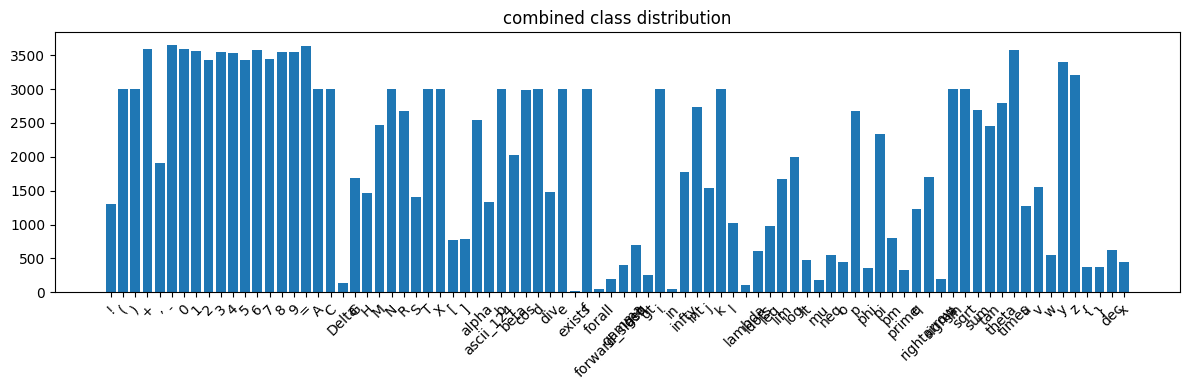

In [11]:
IMG_SIZE = 45
MAX_PER_CLASS_DS1 = 3000  # cap dataset 1 per class to balance with ds2

images = []
labels = []
skipped = 0

def load_from_dataset(root, mapping, max_per_class=None):
    """Load images from a folder-organized dataset."""
    loaded = 0
    skip = 0
    for folder, label in mapping.items():
        folder_path = os.path.join(root, folder)
        img_files = glob.glob(os.path.join(folder_path, '*.jpg')) + \
                    glob.glob(os.path.join(folder_path, '*.png')) + \
                    glob.glob(os.path.join(folder_path, '*.jpeg'))

        if max_per_class and len(img_files) > max_per_class:
            np.random.seed(42)
            img_files = list(np.random.choice(img_files, max_per_class, replace=False))

        for img_path in img_files:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                skip += 1
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            # ensure white-on-black (ink = white pixels)
            if np.mean(img) > 127:
                img = 255 - img

            images.append(img)
            labels.append(label)
            loaded += 1

    return loaded, skip

# load dataset 1 (xainano CROHME)
n1, s1 = load_from_dataset(ds1_root, ds1_mapping, max_per_class=MAX_PER_CLASS_DS1)
print(f'dataset 1: loaded {n1}, skipped {s1}')

# load dataset 2 (sagyamthapa)
if ds2_root and ds2_mapping:
    n2, s2 = load_from_dataset(ds2_root, ds2_mapping)
    print(f'dataset 2: loaded {n2}, skipped {s2}')

print(f'\ntotal: {len(images)} images')
print(f'classes: {sorted(set(labels))}')

# distribution
dist = Counter(labels)
for label, count in sorted(dist.items()):
    print(f'  {label:6s}: {count}')

plt.figure(figsize=(12, 4))
plt.bar(dist.keys(), dist.values())
plt.title('combined class distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
X = np.array(images, dtype=np.float32) / 255.0
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

le = LabelEncoder()
y_encoded = le.fit_transform(labels)
num_classes = len(le.classes_)
y = keras.utils.to_categorical(y_encoded, num_classes)

print(f'X shape: {X.shape}')
print(f'classes ({num_classes}): {list(le.classes_)}')

X shape: (164842, 45, 45, 1)
classes (84): [np.str_('!'), np.str_('('), np.str_(')'), np.str_('+'), np.str_(','), np.str_('-'), np.str_('0'), np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9'), np.str_('='), np.str_('A'), np.str_('C'), np.str_('Delta'), np.str_('G'), np.str_('H'), np.str_('M'), np.str_('N'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('X'), np.str_('['), np.str_(']'), np.str_('alpha'), np.str_('ascii_124'), np.str_('b'), np.str_('beta'), np.str_('cos'), np.str_('d'), np.str_('dec'), np.str_('div'), np.str_('e'), np.str_('exists'), np.str_('f'), np.str_('forall'), np.str_('forward_slash'), np.str_('gamma'), np.str_('geq'), np.str_('gt'), np.str_('i'), np.str_('in'), np.str_('infty'), np.str_('int'), np.str_('j'), np.str_('k'), np.str_('l'), np.str_('lambda'), np.str_('ldots'), np.str_('leq'), np.str_('lim'), np.str_('log'), np.str_('lt'), np.str_('mu'), np.str_('neq'), np.str_('o'), np.str_(

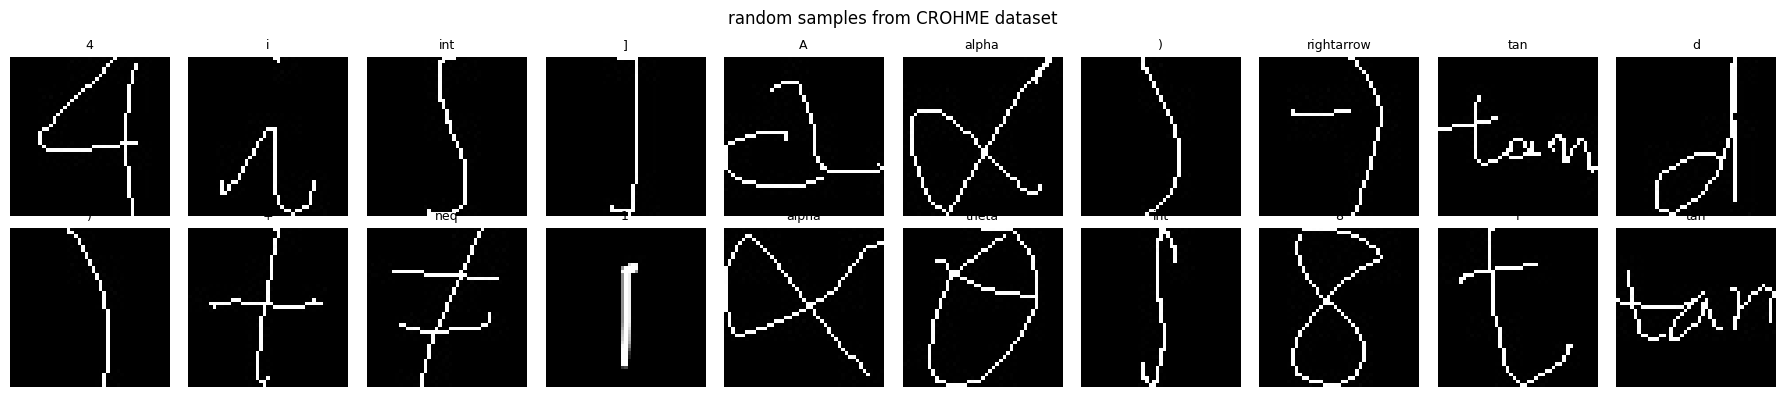

In [13]:
# show some samples
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(len(X))
    ax.imshow(X[idx].squeeze(), cmap='gray')
    ax.set_title(labels[idx], fontsize=9)
    ax.axis('off')
plt.suptitle('random samples from CROHME dataset')
plt.tight_layout()
plt.show()

## Train/val split

In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f'train: {X_train.shape[0]}, val: {X_val.shape[0]}')

train: 131873, val: 32969


## Build CNN

Same architecture as v1 so we can directly compare. 3 conv blocks with batch norm, dense classifier. Input 45x45x1.

In [15]:
model = keras.Sequential([
    # block 1
    layers.Conv2D(32, (3, 3), padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # block 2
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # block 3
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # classifier
    layers.Flatten(),
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 45, 45, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 45, 45, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 45, 45, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 22, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 22, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 22, 22, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 22, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 11, 11, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 982,196 (3.75 MB)

 Trainable params: 981,044 (3.74 MB)

 Non-trainable params: 1,152 (4.50 KB)

## Data augmentation

Same augmentation as v1 -- rotations, shifts, zoom, shear to handle handwriting variation.

In [16]:
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=5,
)
datagen.fit(X_train)

## Train

In [17]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6),
]

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    validation_data=(X_val, y_val),
    epochs=50,
    callbacks=callbacks,
)

Epoch 1/50
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 117s 50ms/step - accuracy: 0.6707 - loss: 1.2212 - val_accuracy: 0.8676 - val_loss: 0.4572 - learning_rate: 0.0010
Epoch 2/50
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 90s 44ms/step - accuracy: 0.8147 - loss: 0.6190 - val_accuracy: 0.8870 - val_loss: 0.3882 - learning_rate: 0.0010
Epoch 3/50
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 90s 44ms/step - accuracy: 0.8456 - loss: 0.5068 - val_accuracy: 0.9123 - val_loss: 0.2907 - learning_rate: 0.0010
Epoch 4/50
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 89s 43ms/step - accuracy: 0.8605 - loss: 0.4517 - val_accuracy: 0.7071 - val_loss: 1.2614 - learning_rate: 0.0010
Epoch 5/50
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 88s 43ms/step - accuracy: 0.8716 - loss: 0.4132 - val_accuracy: 0.7334 - val_loss: 0.9990 - learning_rate: 0.0010
Epoch 6/50
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 141s 42ms/step - accuracy: 0.8779 - loss: 0.3887 - val_accuracy: 0.9353 - val_loss: 0.1955 - learning_rate: 0.0010
Epoch 7/50
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 87s 42ms/step - accu

## Training curves

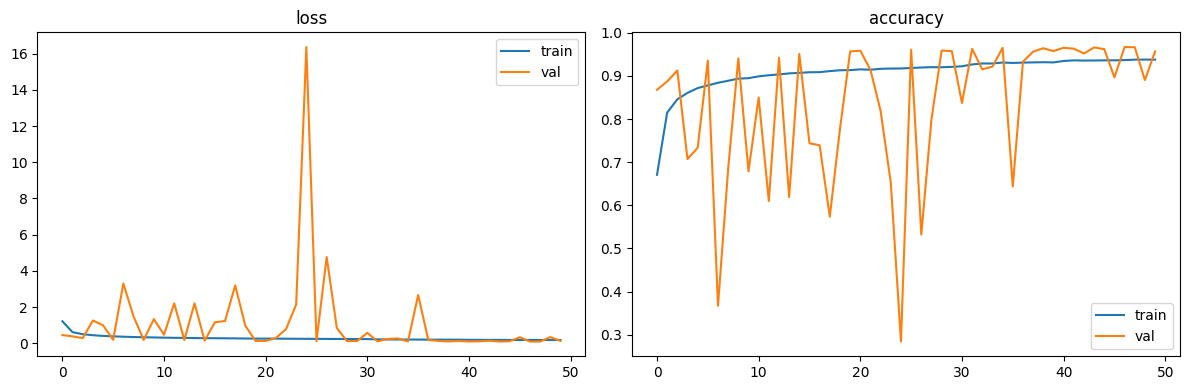

1031/1031 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9667 - loss: 0.1014

val accuracy: 0.9667


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='train')
ax1.plot(history.history['val_loss'], label='val')
ax1.set_title('loss')
ax1.legend()

ax2.plot(history.history['accuracy'], label='train')
ax2.plot(history.history['val_accuracy'], label='val')
ax2.set_title('accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

val_loss, val_acc = model.evaluate(X_val, y_val)
print(f'\nval accuracy: {val_acc:.4f}')

## Confusion matrix

1031/1031 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step


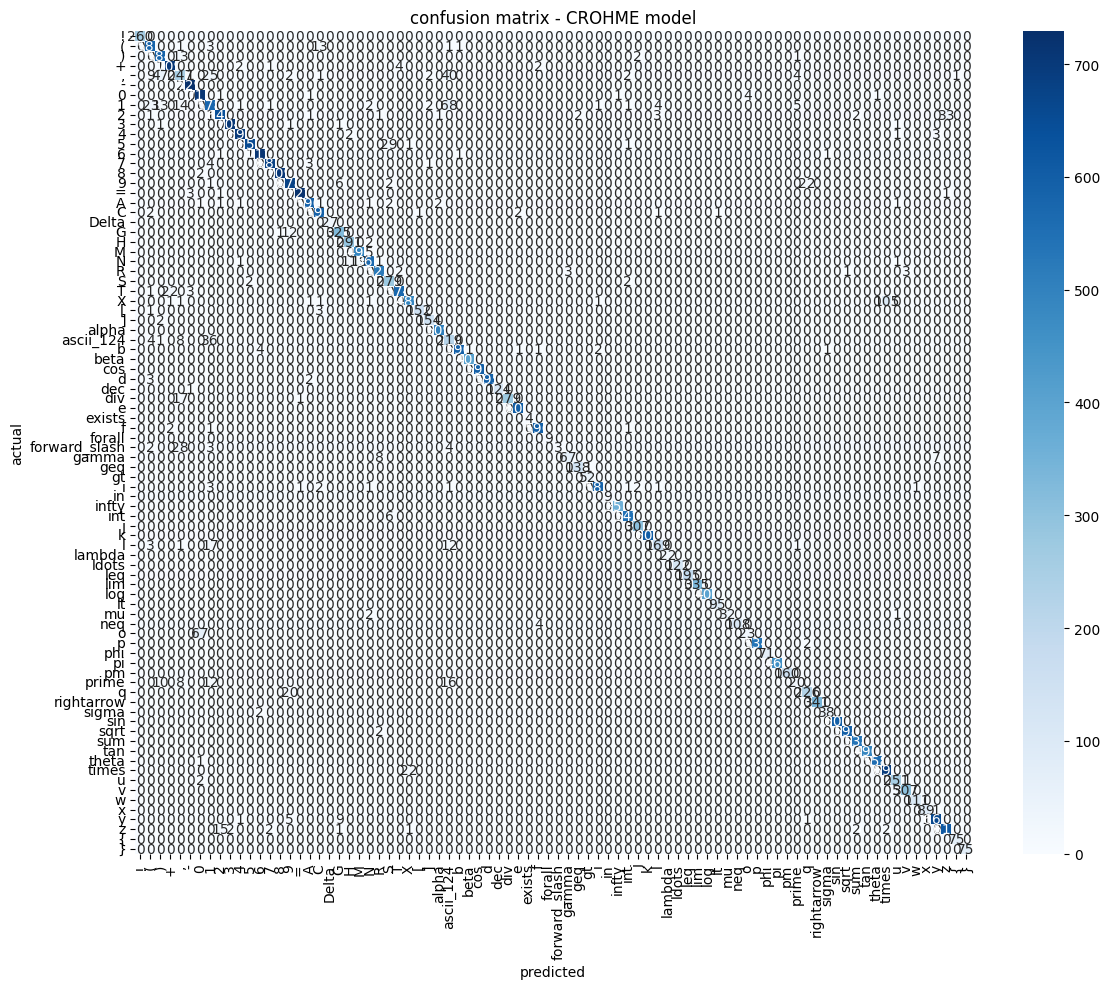

               precision    recall  f1-score   support

            !       1.00      1.00      1.00       260
            (       0.92      0.97      0.94       600
            )       0.89      0.97      0.93       600
            +       0.97      0.99      0.98       719
            ,       0.73      0.65      0.69       381
            -       0.99      1.00      0.99       731
            0       0.91      0.99      0.95       719
            1       0.85      0.81      0.83       713
            2       0.97      0.93      0.95       687
            3       1.00      0.99      1.00       708
            4       0.99      0.99      0.99       705
            5       1.00      0.95      0.97       687
            6       0.99      0.99      0.99       716
            7       0.99      0.99      0.99       689
            8       1.00      1.00      1.00       711
            9       0.94      0.96      0.95       709
            =       1.00      0.99      1.00       727
         

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('confusion matrix - CROHME model')
plt.tight_layout()
plt.show()

print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))

## Save model

Save as `symbol_classifier_crohme.h5` and `label_map_crohme.json`.
After downloading, place in the `models/` folder alongside the v1 model.

In [20]:
# save model
model.save('symbol_classifier_crohme.h5')
print('saved symbol_classifier_crohme.h5')

# save label mapping
label_map = {int(i): name for i, name in enumerate(le.classes_)}
with open('label_map_crohme.json', 'w') as f:
    json.dump(label_map, f, indent=2)
print('saved label_map_crohme.json')
print(f'label map: {label_map}')

saved symbol_classifier_crohme.h5
saved label_map_crohme.json
label map: {0: np.str_('!'), 1: np.str_('('), 2: np.str_(')'), 3: np.str_('+'), 4: np.str_(','), 5: np.str_('-'), 6: np.str_('0'), 7: np.str_('1'), 8: np.str_('2'), 9: np.str_('3'), 10: np.str_('4'), 11: np.str_('5'), 12: np.str_('6'), 13: np.str_('7'), 14: np.str_('8'), 15: np.str_('9'), 16: np.str_('='), 17: np.str_('A'), 18: np.str_('C'), 19: np.str_('Delta'), 20: np.str_('G'), 21: np.str_('H'), 22: np.str_('M'), 23: np.str_('N'), 24: np.str_('R'), 25: np.str_('S'), 26: np.str_('T'), 27: np.str_('X'), 28: np.str_('['), 29: np.str_(']'), 30: np.str_('alpha'), 31: np.str_('ascii_124'), 32: np.str_('b'), 33: np.str_('beta'), 34: np.str_('cos'), 35: np.str_('d'), 36: np.str_('dec'), 37: np.str_('div'), 38: np.str_('e'), 39: np.str_('exists'), 40: np.str_('f'), 41: np.str_('forall'), 42: np.str_('forward_slash'), 43: np.str_('gamma'), 44: np.str_('geq'), 45: np.str_('gt'), 46: np.str_('i'), 47: np.str_('in'), 48: np.str_('inft

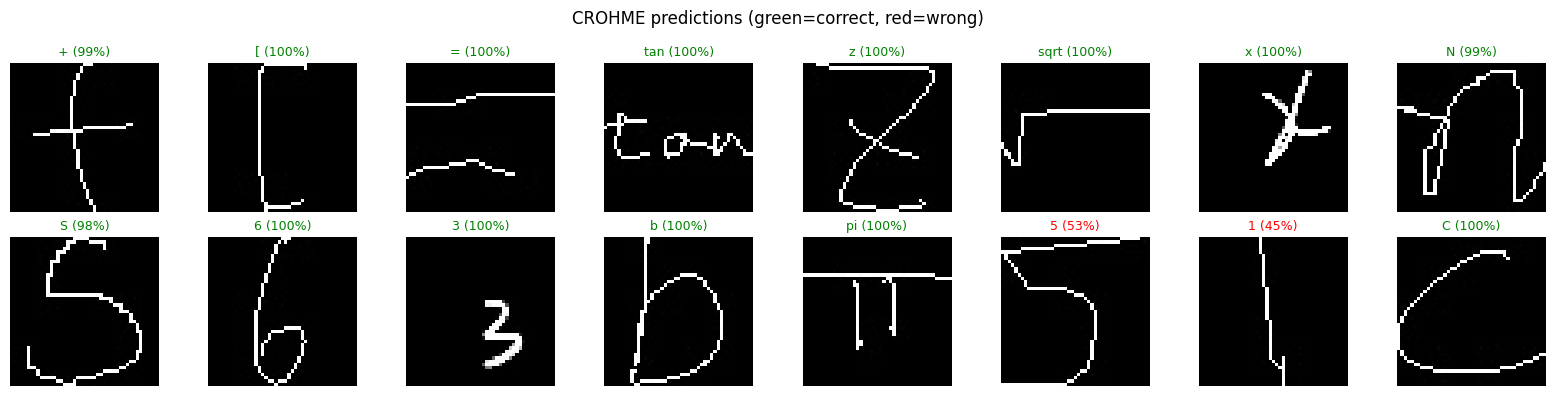

In [21]:
# quick sanity check
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(len(X_val))
    pred = model.predict(X_val[idx:idx+1], verbose=0)
    pred_label = le.classes_[np.argmax(pred)]
    true_label = le.classes_[np.argmax(y_val[idx])]
    conf = np.max(pred) * 100
    color = 'green' if pred_label == true_label else 'red'
    ax.imshow(X_val[idx].squeeze(), cmap='gray')
    ax.set_title(f'{pred_label} ({conf:.0f}%)', color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('CROHME predictions (green=correct, red=wrong)')
plt.tight_layout()
plt.show()

## Copy to project

Download `symbol_classifier_crohme.h5` and `label_map_crohme.json` and put them in the `models/` folder.

Then update `src/model.py` to point to the new model files.

In [22]:
from google.colab import files
files.download('symbol_classifier_crohme.h5')
files.download('label_map_crohme.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>